In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [27]:
import numpy as np

df['Sex'] = df['Sex'].astype(str).str.lower().map({'male': 0, 'female': 1})
df['Sex'] = df['Sex'].fillna(-1)

In [26]:
if 'Embarked' in df.columns:
    df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
    print("Column 'Embarked' has been one-hot encoded.")
else:
    print("Column 'Embarked' not found. It may have already been processed.")

Column 'Embarked' not found. It may have already been processed.


In [28]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [29]:
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0       3 -1.0  22.0      1      0   7.2500       False        True
1       1 -1.0  38.0      1      0  71.2833       False       False
2       3 -1.0  26.0      0      0   7.9250       False        True
3       1 -1.0  35.0      1      0  53.1000       False        True
4       3 -1.0  35.0      0      0   8.0500       False        True

Target (y):
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7263


In [34]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7263


In [35]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.89      0.79       105
           1       0.76      0.50      0.60        74

    accuracy                           0.73       179
   macro avg       0.74      0.69      0.70       179
weighted avg       0.73      0.73      0.71       179



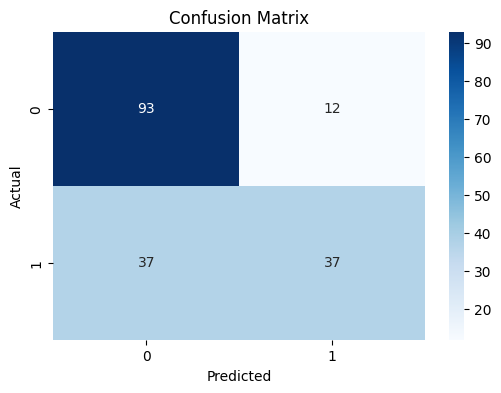

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

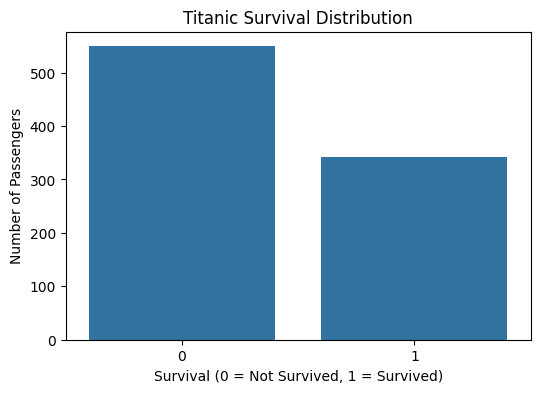

In [37]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Survived")

plt.title("Titanic Survival Distribution")
plt.xlabel("Survival (0 = Not Survived, 1 = Survived)")
plt.ylabel("Number of Passengers")

plt.show()

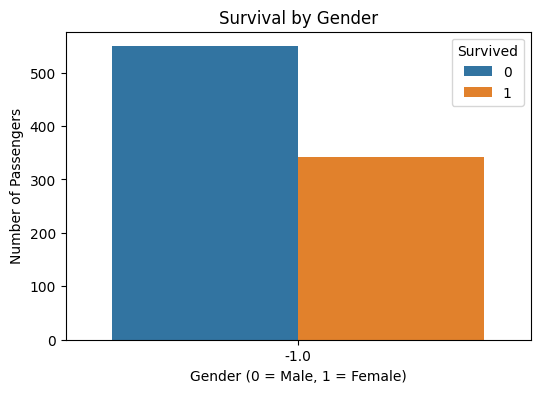

In [38]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender (0 = Male, 1 = Female)")
plt.ylabel("Number of Passengers")

plt.show()

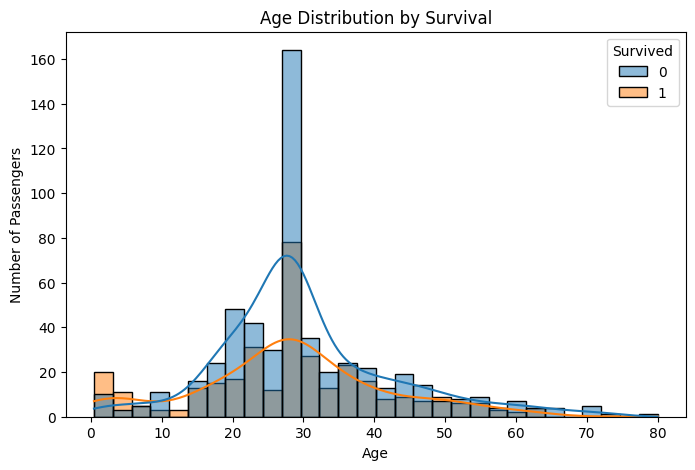

In [39]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

# Titanic Survival Prediction

## Objective

The objective of this project is to build a machine learning model that predicts whether a passenger survived the Titanic disaster based on passenger-related features.

## Dataset

The dataset contains passenger information such as passenger class, gender, age, number of siblings/spouses, parents/children aboard, fare, and embarkation information.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Machine Learning Algorithm

Logistic Regression

# Conclusion

In this project, a Logistic Regression model was developed to predict Titanic passenger survival.

The dataset was cleaned and preprocessed before training the model. Missing values were handled, categorical features were converted into numerical form, and the dataset was divided into training and testing sets.

The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The results demonstrate how machine learning can be applied to a classification problem using passenger data.